In [24]:
%pip uninstall -y pyfolio
%pip install -U pip setuptools wheel
%pip install pyfolio-reloaded

In [25]:
import yfinance as yf
import pandas as pd
import numpy as np

from xgboost import XGBRegressor
from xgboost.core import XGBoostError
import pyfolio as pf
from tqdm import tqdm


## Using ML for Portfolio Factors Strategy

From a pool of stocks, we run XGBoost regression on a backtest window with start and end dates.

In [26]:
# ----------------------------
# 1. Parameters
# ----------------------------

# Method A: Use more stocks
# 扩大股票池，不再只用原来的 5 只股票
tickers = [
    "AAPL","MSFT","GOOG","AMZN","TSLA",
    "META","NVDA","NFLX","AMD","INTC",
    "JPM","BAC","WFC","GS","MS",
    "XOM","CVX","JNJ","PFE","UNH",
    "KO","PEP","MCD","WMT","COST",
    "HD","LOW","DIS","CRM","ORCL"
]

# Method B: Do over a longer period of time for more robustness in results
# 把回测时间拉长，减少结果只受某一两年影响
start_date = "2016-01-01"
end_date = "2025-12-01"

In [27]:
# 保留原来的核心滚动预测逻辑
lookback = 60             # days for feature calculation
prediction_horizon = 20   # days ahead return
train_window = 252        # rolling training window (1 year)

# Method A: 股票池扩大后，不再只做 top 2 / bottom 2
top_n = 5
bottom_n = 5

transaction_cost = 0.001  # 0.1% per trade

# Method C: Use a more stringent filter
# 过滤掉历史数据覆盖不足、可用样本太少的股票
min_coverage_ratio = 0.90
min_required_obs = train_window + lookback + prediction_horizon + 20

In [28]:
# ----------------------------
# 2. Download price data
# ----------------------------

prices = yf.download(tickers, start=start_date, end=end_date)['Close']

# 保证即使只剩 1 只股票时也仍然是 DataFrame
if isinstance(prices, pd.Series):
    prices = prices.to_frame()

# Method C: Use a more stringent filter
# 1) 要求历史数据覆盖率足够高
# 2) 要求总可用观测数足够多
coverage_ratio = prices.notna().mean()
obs_count = prices.notna().sum()

eligible_tickers = coverage_ratio[
    (coverage_ratio >= min_coverage_ratio) &
    (obs_count >= min_required_obs)
].index.tolist()

prices = prices[eligible_tickers].copy()

# 删除全为空的日期
prices = prices.dropna(how='all')

# 更新过滤后的股票池
tickers = prices.columns.tolist()

# 收益率
returns = prices.pct_change().fillna(0)

# Download benchmark
benchmark = yf.download("SPY", start=start_date, end=end_date)['Close'].pct_change()

# 对齐 benchmark 到策略收益日期
benchmark = benchmark.reindex(returns.index).fillna(0)

print("Number of selected stocks after stricter filter:", len(tickers))
print("Selected tickers:", tickers)

/tmp/ipykernel_1610/1991671429.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  30 of 30 completed
/tmp/ipykernel_1610/1991671429.py:34: FutureWarning: YF.download() has changed argument auto_adjust default to True
  benchmark = yf.download("SPY", start=start_date, end=end_date)['Close'].pct_change()
[*********************100%***********************]  1 of 1 completed

Number of selected stocks after stricter filter: 30
Selected tickers: ['AAPL', 'AMD', 'AMZN', 'BAC', 'COST', 'CRM', 'CVX', 'DIS', 'GOOG', 'GS', 'HD', 'INTC', 'JNJ', 'JPM', 'KO', 'LOW', 'MCD', 'META', 'MS', 'MSFT', 'NFLX', 'NVDA', 'ORCL', 'PEP', 'PFE', 'TSLA', 'UNH', 'WFC', 'WMT', 'XOM']


Compute the features - momentum and volatility to use as predictors. These are very elementary for now. The predictors need to be changed here.

In [29]:
# ----------------------------
# 3. Compute features
# ----------------------------
momentum = prices.pct_change(lookback).shift(1)
volatility = prices.pct_change().rolling(lookback).std().shift(1)
features = pd.concat([momentum.add_suffix('_mom'), volatility.add_suffix('_vol')], axis=1).dropna()


In [30]:
# Target: forward returns
future_returns = prices.pct_change(prediction_horizon).shift(-prediction_horizon)
future_returns = future_returns.loc[features.index]

In [31]:
# ----------------------------
# 4. Rolling ML factor prediction
# Improvement: remove look-ahead bias by purging the most recent prediction_horizon observations
# 目标：在 date 做预测时，不使用那些“到 date 这天还没有完全实现未来收益”的训练样本
# ----------------------------

from pandas.tseries.offsets import BDay

predicted_signal = pd.DataFrame(index=features.index, columns=tickers, dtype=float)
dates = features.index[train_window:]

for date in tqdm(dates, desc="ML factor backtest (purged training)"):
    train_start = date - pd.Timedelta(days=train_window)

    # 关键改动：
    # 只保留那些其 future return 在当前预测日之前已经完全实现的样本
    # 比如 prediction_horizon = 20，那么离当前 date 太近的最近 20 个交易日样本不能用于训练
    max_train_date = date - BDay(prediction_horizon + 1)

    # 如果没有足够训练区间，就跳过
    if max_train_date <= train_start:
        continue

    X_train_full = features.loc[train_start:max_train_date].copy()

    if X_train_full.empty:
        continue

    y_train_full = future_returns.loc[X_train_full.index].copy()

    for ticker in tickers:
        try:
            cols = [ticker + '_mom', ticker + '_vol']

            # 合并 X 和 y 后统一 dropna，避免长度错位
            train_df = pd.concat([X_train_full[cols], y_train_full[[ticker]]], axis=1).dropna()

            # 样本太少则跳过
            if len(train_df) < 100:
                continue

            model = XGBRegressor(
                n_estimators=50,
                max_depth=3,
                learning_rate=0.1,
                random_state=42
            )

            model.fit(train_df[cols], train_df[ticker])

            # 如果测试日特征缺失，则跳过该股票
            if features.loc[date, cols].isna().any():
                continue

            X_test = features.loc[date, cols].values.reshape(1, -1)
            predicted_signal.loc[date, ticker] = model.predict(X_test)[0]

        except XGBoostError:
            print("No prediction for 20 days ahead: " + str(date))
            print("Ticker is: " + ticker)
            continue

ML factor backtest (purged training): 100%|██████████| 2179/2179 [27:00<00:00,  1.34it/s]


In [32]:
# ----------------------------
# 5. Monthly rebalancing
# Improvement: execute on the next trading day instead of the same signal day
# 目标：避免“今天生成信号、今天就按这个信号赚到当天收益”的时序偏差
# ----------------------------

# 仍然保留月末信号调仓
predicted_signal = predicted_signal.resample('M').last()

weights = pd.DataFrame(0.0, index=predicted_signal.index, columns=predicted_signal.columns)

signal_rank = predicted_signal.rank(axis=1, ascending=False, method='first')

long_mask = signal_rank <= top_n
short_mask = signal_rank >= (len(tickers) - bottom_n + 1)

# 等权 long-short
weights[long_mask] = 1.0 / top_n
weights[short_mask] = -1.0 / bottom_n

# 对齐到日频收益
weights = weights.reindex(returns.index).ffill()

# 关键改动：
# 信号当天不立即生效，而是下一个交易日才真正持仓
weights = weights.shift(1).fillna(0.0)

/tmp/ipykernel_1610/359231870.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  predicted_signal = predicted_signal.resample('M').last()


### Rationale of the backtest restuls
- On date of test, use the XGBoost model to find the relationship between the factors and the projected future return known on hindsight (for each stock).
- Sort the predicted return. Long the highest value and short the lowest value at the end of the month.
- At the next month, do the same and re-adjust the portfolio based on the long/short stocks.
![Backtest_Factors.png](attachment:ba29190d-289e-4fa3-b5d7-81a1b94693ab.png)


In [33]:
# ----------------------------
# 6. Apply transaction costs
# ----------------------------
weight_change = weights.diff().abs().sum(axis=1)
daily_returns = (weights * returns).sum(axis=1)
daily_returns = daily_returns - weight_change * transaction_cost

### Portfolio Backtest Results

Note the backtest results are based on daily returns, although rebalancing is done monthly. This means the returns are not all realised. (but unrealised)

/usr/local/lib/python3.12/dist-packages/pyfolio/plotting.py:670: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-9.162%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  perf_stats.loc[stat, column] = str(np.round(value * 100, 3)) + "%"


Start date,2016-01-04
End date,2025-11-28
Total months,118
,Backtest
Annual return,-9.162%
Cumulative returns,-61.335%
Annual volatility,21.894%
Sharpe ratio,-0.33
Calmar ratio,-0.15
Stability,0.72
Max drawdown,-63.055%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,63.05,2017-04-03,2025-11-25,NaT,NaN
1,NaN,NaT,NaT,NaT,NaN
2,NaN,NaT,NaT,NaT,NaN
3,NaN,NaT,NaT,NaT,NaN
4,NaN,NaT,NaT,NaT,NaN


/usr/local/lib/python3.12/dist-packages/pyfolio/plotting.py:1407: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Daily", "Weekly", "Monthly"])
/usr/local/lib/python3.12/dist-packages/pyfolio/tears.py:1005: UserWarning: Passed returns do not overlap with anyinteresting times.
  warnings.warn(


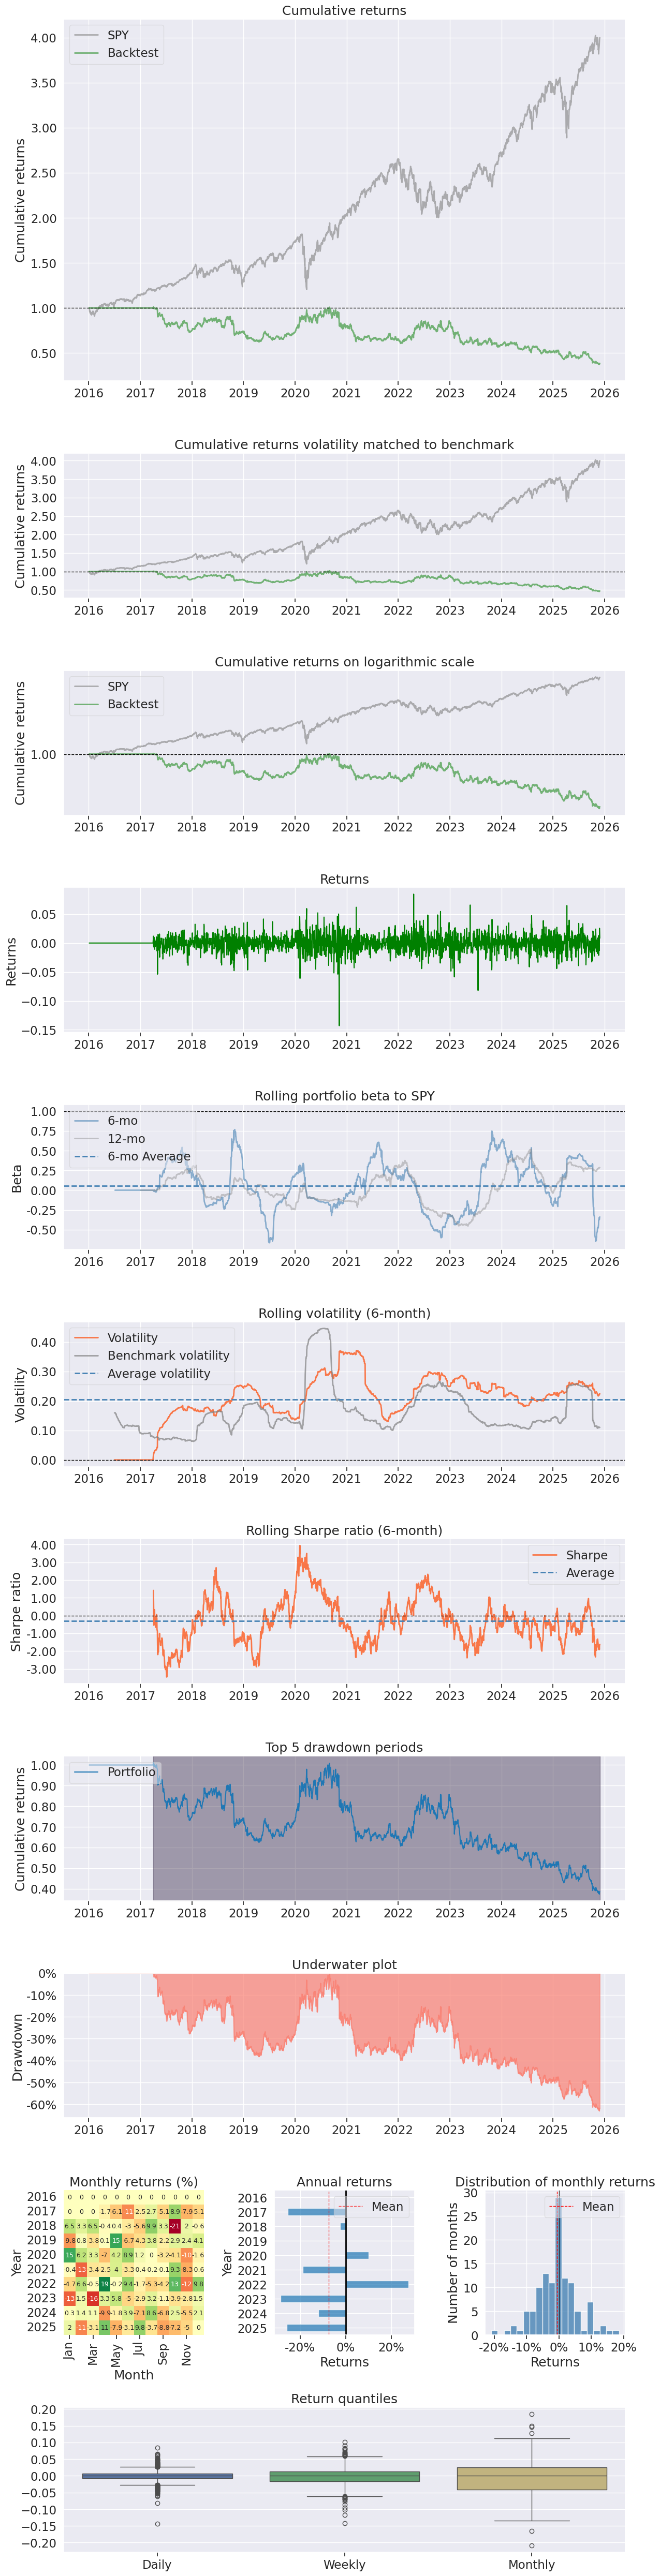

In [34]:
# ----------------------------
# 7. PyFolio analysis
# ----------------------------
# remove the initial 60 days lookback period
daily_returns = daily_returns.replace([np.inf, -np.inf], np.nan).dropna()
pf.create_full_tear_sheet(daily_returns.squeeze(), benchmark_rets=benchmark.squeeze())


### Comments on strategy
- The strategy outperformed the S\&P 500 index over the whole period. Although it must be noted that most of the gains occured in the year 2025.
- DUring the second half of 2024, the strategy did not do well, and fell almost 28% which took almost 4-5 months to recover.

### Exercise
- As part of the exercise, how will you improve the strategy?
    - Use more stocks
    - Do over a longer period of time for more robustness in results
    - Use another ML method.
    - Use a more stringent filter (with more stocks availability)
    - Use only long strategy (stocks) as a constraint.
    - Use other features (fundamentals eg) Note though these data available on a quarterly basis.
